# BdG Tight-Binding Discretization

The **Bogoliubov–de Gennes (BdG)** formalism is the fully microscopic approach to
inhomogeneous superconductivity. Rather than averaging over impurities (as in the
quasiclassical Usadel theory), BdG retains the full lattice-scale detail, making it
the method of choice when the relevant length scales approach the Fermi wavelength.

## Physical Motivation

In a superconductor, electrons near the Fermi surface pair into Cooper pairs
described by a pairing potential $\Delta(\mathbf{r})$. In spatially inhomogeneous
systems — interfaces, vortices, thin films — $\Delta$ varies in space and must be
determined self-consistently.

The BdG equations diagonalize the mean-field Hamiltonian, yielding
quasiparticle wavefunctions $(u_n, v_n)$ and energies $E_n$. These are the
superconducting analogue of the Schrödinger equation, coupling electron-like and
hole-like excitations through the pair potential.

## The BdG Hamiltonian

On a 1D tight-binding lattice with $N$ sites, nearest-neighbor hopping $t$,
on-site pairing $\Delta_i$, and exchange field $h_i$, the Hamiltonian is:

$$
\hat{H} = \sum_{i,\sigma} \left( -t\, c_{i\sigma}^\dagger c_{i+1,\sigma}
+ \text{h.c.} \right)
+ \sum_i \left( \Delta_i\, c_{i\uparrow}^\dagger c_{i\downarrow}^\dagger
+ \text{h.c.} \right)
+ \sum_i h_i \left( n_{i\uparrow} - n_{i\downarrow} \right)
$$

In matrix form, this is a $2N \times 2N$ eigenvalue problem in the
Nambu basis $\Psi_i = (c_{i\uparrow},\, c_{i\downarrow}^\dagger)^T$:

$$
\begin{pmatrix}
\hat{H}_0 - \mu + h & \hat{\Delta} \\
\hat{\Delta}^\dagger & -(\hat{H}_0 - \mu + h)^*
\end{pmatrix}
\begin{pmatrix} u_n \\ v_n \end{pmatrix}
= E_n \begin{pmatrix} u_n \\ v_n \end{pmatrix}
$$

where $\hat{H}_0$ is the kinetic (hopping) matrix and $\hat{\Delta}$ is the
diagonal pairing matrix.

## Self-Consistency Condition

The pair potential $\Delta_i$ is not an input — it must be determined
self-consistently from the eigenstates:

$$
\Delta_i = -V \sum_n u_n(i)\, v_n^*(i)\, \tanh\!\left(\frac{E_n}{2 k_B T}\right)
$$

Here $V > 0$ is the pairing interaction strength. The sum runs over all
positive-energy eigenstates (or equivalently, all states with appropriate
thermal weighting). The $\tanh$ factor is the Fermi occupation function
at temperature $T$.

### Iteration Procedure

1. Start with an initial guess $\Delta_i^{(0)}$ (e.g., the bulk BCS value in S, zero in F)
2. Construct and diagonalize the $2N \times 2N$ BdG matrix
3. Compute new $\Delta_i^{(n+1)}$ from the eigenstates
4. Mix: $\Delta_i \leftarrow \alpha\, \Delta_i^{(n+1)} + (1-\alpha)\, \Delta_i^{(n)}$
5. Repeat until $\max_i |\Delta_i^{(n+1)} - \Delta_i^{(n)}| < \epsilon$

## Tight-Binding Matrix Structure

The BdG matrix has a block-tridiagonal structure. For site $i$, the on-site
block is:

$$
\mathcal{H}_{ii} = \begin{pmatrix}
\epsilon_i - \mu + h_i & \Delta_i \\
\Delta_i^* & -(\epsilon_i - \mu + h_i)
\end{pmatrix}
$$

and the hopping block connecting sites $i$ and $i+1$ is:

$$
\mathcal{T}_{i,i+1} = \begin{pmatrix}
-t & 0 \\
0 & t
\end{pmatrix}
$$

The particle-hole symmetry of BdG guarantees that eigenvalues come in
pairs $\pm E_n$, which halves the computational work.

In [1]:
import numpy as np

def build_bdg_matrix(N, t, mu, Delta, h):
    """
    Construct the 2N x 2N BdG Hamiltonian for a 1D chain.
    
    Parameters
    ----------
    N : int          – number of lattice sites
    t : float        – hopping parameter (eV)
    mu : float       – chemical potential (eV)
    Delta : array    – pairing potential at each site (length N)
    h : array        – exchange field at each site (length N)
    
    Returns
    -------
    H : ndarray, shape (2N, 2N)
    """
    H = np.zeros((2*N, 2*N), dtype=complex)
    
    for i in range(N):
        # On-site: electron block
        H[i, i] = -mu + h[i]
        # On-site: hole block
        H[N+i, N+i] = mu - h[i]
        # Pairing
        H[i, N+i] = Delta[i]
        H[N+i, i] = np.conj(Delta[i])
    
    for i in range(N - 1):
        # Hopping: electron block
        H[i, i+1] = -t
        H[i+1, i] = -t
        # Hopping: hole block
        H[N+i, N+i+1] = t
        H[N+i+1, N+i] = t
    
    return H

# Example: 20-site S/F bilayer (10 S + 10 F sites)
N = 20
t, mu = 1.0, 0.0
Delta = np.array([0.1]*10 + [0.0]*10)   # pairing in S only
h = np.array([0.0]*10 + [0.3]*10)        # exchange in F only

H = build_bdg_matrix(N, t, mu, Delta, h)
energies = np.linalg.eigvalsh(H)

print(f"Lowest quasiparticle energies: {np.sort(np.abs(energies))[:6].round(4)}")
print(f"Matrix size: {H.shape}")
print(f"Particle-hole symmetry check: E and -E pairs")
print(f"  Positive: {np.sort(energies[energies > 0])[:3].round(4)}")
print(f"  Negative: {np.sort(-energies[energies < 0])[:3].round(4)}")

Lowest quasiparticle energies: [0.0457 0.0457 0.3009 0.3009 0.3095 0.3095]
Matrix size: (40, 40)
Particle-hole symmetry check: E and -E pairs
  Positive: [0.0457 0.3009 0.3095]
  Negative: [0.0457 0.3009 0.3095]


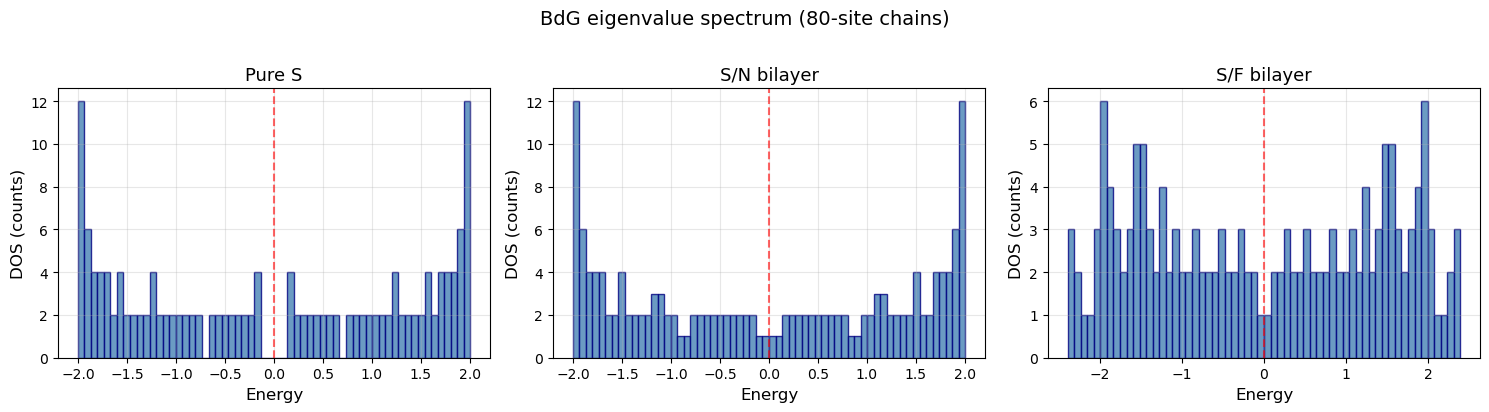

In [2]:
# BdG eigenvalue spectrum histogram for S/F bilayer
import numpy as np
import matplotlib.pyplot as plt

def build_bdg_matrix(N, t, mu, Delta, h):
    H = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(N):
        H[i, i] = -mu + h[i]
        H[N+i, N+i] = mu - h[i]
        H[i, N+i] = Delta[i]
        H[N+i, i] = np.conj(Delta[i])
    for i in range(N - 1):
        H[i, i+1] = -t; H[i+1, i] = -t
        H[N+i, N+i+1] = t; H[N+i+1, N+i] = t
    return H

N = 80
t, mu = 1.0, 0.0
N_S, N_F = 40, 40

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    ('Pure S', np.full(N, 0.15), np.zeros(N)),
    ('S/N bilayer', np.array([0.15]*N_S + [0.0]*N_F), np.zeros(N)),
    ('S/F bilayer', np.array([0.15]*N_S + [0.0]*N_F), np.array([0.0]*N_S + [0.4]*N_F)),
]

for ax, (title, Delta, h) in zip(axes, configs):
    H = build_bdg_matrix(N, t, mu, Delta, h)
    E = np.linalg.eigvalsh(H)
    ax.hist(E, bins=60, color='steelblue', edgecolor='navy', alpha=0.8)
    ax.axvline(0, ls='--', color='red', alpha=0.6)
    ax.set_xlabel('Energy', fontsize=12)
    ax.set_ylabel('DOS (counts)', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3)

fig.suptitle('BdG eigenvalue spectrum (80-site chains)', fontsize=14, y=1.02)
fig.tight_layout(); plt.show()

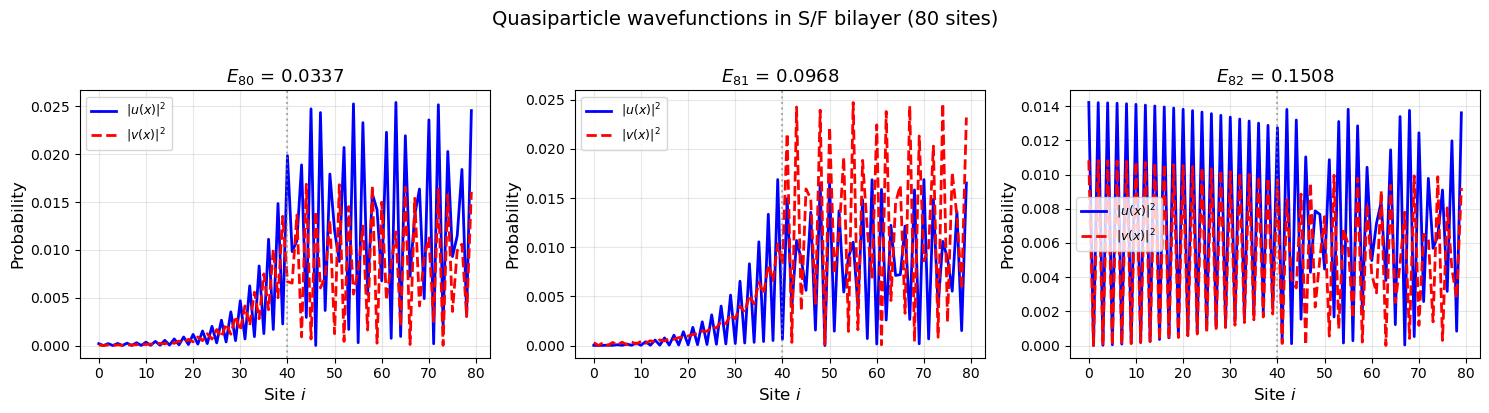

In [3]:
# Quasiparticle wavefunctions: spatial profiles of lowest-energy BdG eigenstates
import numpy as np
import matplotlib.pyplot as plt

def build_bdg_matrix(N, t, mu, Delta, h):
    H = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(N):
        H[i, i] = -mu + h[i]
        H[N+i, N+i] = mu - h[i]
        H[i, N+i] = Delta[i]
        H[N+i, i] = np.conj(Delta[i])
    for i in range(N - 1):
        H[i, i+1] = -t; H[i+1, i] = -t
        H[N+i, N+i+1] = t; H[N+i+1, N+i] = t
    return H

N = 80; N_S = 40; N_F = 40
t, mu = 1.0, 0.0
Delta = np.array([0.15]*N_S + [0.0]*N_F)
h_field = np.array([0.0]*N_S + [0.4]*N_F)
H = build_bdg_matrix(N, t, mu, Delta, h_field)
E, V = np.linalg.eigh(H)

# Select lowest 3 positive-energy states
pos_idx = np.where(E > 0)[0][:3]
sites = np.arange(N)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx in zip(axes, pos_idx):
    u = V[:N, idx]       # electron component
    v = V[N:, idx]       # hole component
    ax.plot(sites, np.abs(u)**2, 'b-', lw=2, label=r'$|u(x)|^2$')
    ax.plot(sites, np.abs(v)**2, 'r--', lw=2, label=r'$|v(x)|^2$')
    ax.axvline(N_S, ls=':', color='grey', alpha=0.6)
    ax.set_xlabel('Site $i$', fontsize=12)
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_title(f'$E_{{{idx}}}$ = {E[idx]:.4f}', fontsize=13)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('Quasiparticle wavefunctions in S/F bilayer (80 sites)', fontsize=14, y=1.02)
fig.tight_layout(); plt.show()

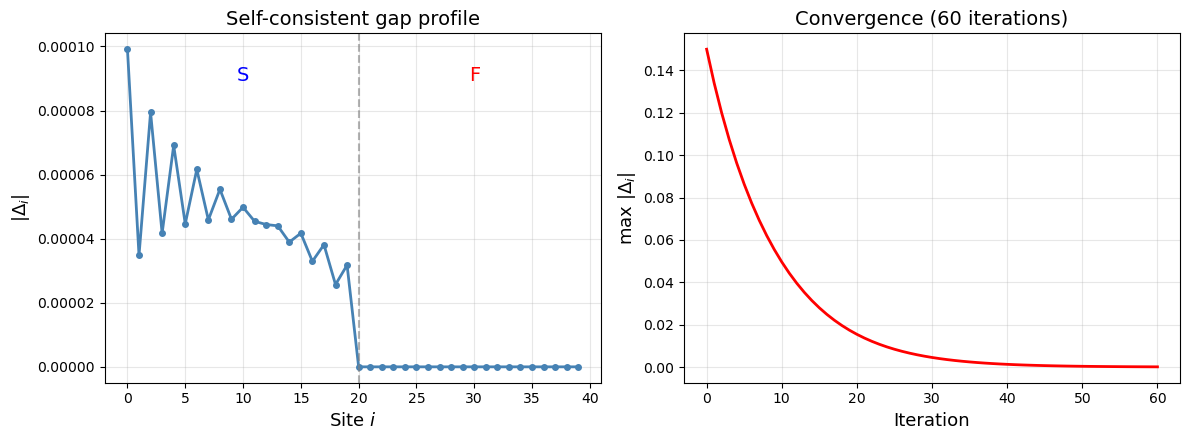

In [4]:
# Self-consistent BdG iteration for a small S/F bilayer
import numpy as np
import matplotlib.pyplot as plt

def build_bdg(N, t, mu, Delta, h):
    H = np.zeros((2*N, 2*N), dtype=complex)
    for i in range(N):
        H[i, i] = -mu + h[i]
        H[N+i, N+i] = mu - h[i]
        H[i, N+i] = Delta[i]
        H[N+i, i] = np.conj(Delta[i])
    for i in range(N-1):
        H[i, i+1] = -t; H[i+1, i] = -t
        H[N+i, N+i+1] = t; H[N+i+1, N+i] = t
    return H

N = 40; N_S = 20; N_F = 20
t, mu = 1.0, 0.0
V_pair = 0.5       # pairing interaction (S sites only)
h_field = np.array([0.0]*N_S + [0.3]*N_F)
T_eff = 0.02       # effective temperature

Delta = np.array([0.15]*N_S + [0.0]*N_F, dtype=complex)
alpha = 0.2         # mixing parameter
history = [Delta.copy()]

for iteration in range(60):
    H = build_bdg(N, t, mu, Delta, h_field)
    E, W = np.linalg.eigh(H)
    Delta_new = np.zeros(N, dtype=complex)
    for i in range(N_S):  # pairing only in S
        for n in range(2*N):
            if E[n] > 0:
                Delta_new[i] += V_pair * W[i, n] * np.conj(W[N+i, n]) * np.tanh(E[n] / (2*T_eff))
    Delta = alpha * Delta_new + (1 - alpha) * Delta
    history.append(Delta.copy())
    if np.max(np.abs(Delta - history[-2])) < 1e-6:
        break

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: converged gap profile
axes[0].plot(range(N), np.abs(Delta), 'o-', color='steelblue', lw=2, ms=4)
axes[0].axvline(N_S, ls='--', color='grey', alpha=0.6)
axes[0].text(N_S/2, np.max(np.abs(Delta))*0.9, 'S', fontsize=14, ha='center', color='blue')
axes[0].text(N_S + N_F/2, np.max(np.abs(Delta))*0.9, 'F', fontsize=14, ha='center', color='red')
axes[0].set_xlabel('Site $i$', fontsize=13)
axes[0].set_ylabel(r'$|\Delta_i|$', fontsize=13)
axes[0].set_title('Self-consistent gap profile', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Right: convergence
max_delta = [np.max(np.abs(history[k][:N_S])) for k in range(len(history))]
axes[1].plot(max_delta, 'r-', lw=2)
axes[1].set_xlabel('Iteration', fontsize=13)
axes[1].set_ylabel(r'max $|\Delta_i|$', fontsize=13)
axes[1].set_title(f'Convergence ({len(history)-1} iterations)', fontsize=14)
axes[1].grid(True, alpha=0.3)

fig.tight_layout(); plt.show()

## Numerical Considerations

| Aspect | Detail |
|--------|--------|
| **Scaling** | Full diagonalization costs $\mathcal{O}(N^3)$; limits practical sizes to $N \lesssim 10^3$ sites |
| **Cutoff** | The Matsubara sum must be cut at $\omega_D$ (Debye frequency) to avoid ultraviolet divergence |
| **Mixing** | Self-consistency requires under-relaxation ($\alpha \sim 0.1{-}0.3$) for convergence |
| **Sparse solvers** | For large $N$, use iterative eigensolvers (Lanczos) targeting states near $E = 0$ |
| **Block structure** | The tridiagonal block form enables $\mathcal{O}(N)$ algorithms when combined with the recursion method |

## References

1. de Gennes, P.G., *Superconductivity of Metals and Alloys* (W.A. Benjamin, 1966).
2. Bagwell, P.F., "Suppression of the Josephson current through a narrow, mesoscopic, semiconductor channel by a single impurity," Phys. Rev. B **49**, 6841 (1994).
3. Zhu, J.-X., *Bogoliubov–de Gennes Method and Its Applications*, Lecture Notes in Physics 924 (Springer, 2016).